# Autonomous Spacecraft Navigation in Dynamic Asteroid Fields

This notebook simulates a spacecraft moving from a start point to a goal while avoiding moving asteroids in a 2D space. The main goal is to compare a few common motion planning methods in the same environment and see how they behave.

The code is kept pretty simple on purpose. It is written in a clean student style so it is easier to read, explain, and run from top to bottom in Jupyter Notebook.

## 1. Introduction

The spacecraft moves in a `1000 x 1000` space and tries to reach the goal at the top-right side of the map. At the same time, 34 asteroids move with their own velocities and bounce off the walls.

The algorithms compared here are:

- A*
- Greedy Best First Search
- RRT
- RRT*
- Potential Field

For each algorithm, the notebook stores:

- asteroid history
- spacecraft trail
- path history
- total path length
- planning time
- success or failure
- number of collisions

In [3]:
# 2. Import Libraries

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
from IPython.display import display
import random
import time
import math
import os
import tempfile

plt.rcParams["figure.figsize"] = (8, 8)
plt.rcParams["axes.facecolor"] = "#07111f"
plt.rcParams["figure.facecolor"] = "white"

random.seed(7)
np.random.seed(7)

# Create output directories
os.makedirs("gifs", exist_ok=True)
os.makedirs("images", exist_ok=True)
os.makedirs(".animation_temp", exist_ok=True)
tempfile.tempdir = os.path.abspath(".animation_temp")

In [4]:
# 3. Environment Setup

SPACE_WIDTH = 1000
SPACE_HEIGHT = 1000

START = np.array([50.0, 50.0])
GOAL = np.array([950.0, 950.0])

ASTEROID_COUNT = 34
GRID_SIZE = 50
MAX_STEPS = 320
SPACECRAFT_SPEED = 18.0
GOAL_RADIUS = 25.0
REPLAN_INTERVAL = 6


def euclidean(a, b):
    a = np.array(a, dtype=float)
    b = np.array(b, dtype=float)
    return float(np.linalg.norm(a - b))


def clamp_point(point):
    x = min(max(point[0], 0.0), SPACE_WIDTH)
    y = min(max(point[1], 0.0), SPACE_HEIGHT)
    return np.array([x, y], dtype=float)


def direction_vector(a, b):
    a = np.array(a, dtype=float)
    b = np.array(b, dtype=float)
    vec = b - a
    norm = np.linalg.norm(vec)
    if norm < 1e-9:
        return np.zeros(2, dtype=float)
    return vec / norm


def total_path_length(points):
    if len(points) < 2:
        return 0.0

    total = 0.0
    for i in range(1, len(points)):
        total += euclidean(points[i - 1], points[i])
    return total


def set_run_seed(seed_value):
    random.seed(seed_value)
    np.random.seed(seed_value)

In [5]:
# 4. Asteroid Class

class Asteroid:
    def __init__(self, position, velocity, radius):
        self.position = np.array(position, dtype=float)
        self.velocity = np.array(velocity, dtype=float)
        self.radius = float(radius)

    def move(self):
        # update asteroid positions
        self.position = self.position + self.velocity

        if self.position[0] - self.radius <= 0 or self.position[0] + self.radius >= SPACE_WIDTH:
            self.velocity[0] *= -1
            self.position[0] = min(max(self.position[0], self.radius), SPACE_WIDTH - self.radius)

        if self.position[1] - self.radius <= 0 or self.position[1] + self.radius >= SPACE_HEIGHT:
            self.velocity[1] *= -1
            self.position[1] = min(max(self.position[1], self.radius), SPACE_HEIGHT - self.radius)

    def copy(self):
        return Asteroid(self.position.copy(), self.velocity.copy(), self.radius)

In [6]:
# 5. Spacecraft Class

class Spacecraft:
    def __init__(self, start):
        self.start = np.array(start, dtype=float)
        self.position = np.array(start, dtype=float)
        self.trail = [self.position.copy()]
        self.current_path = []

    def set_path(self, path_points):
        self.current_path = [np.array(p, dtype=float) for p in path_points]

    def move_toward(self, target, step_size=SPACECRAFT_SPEED):
        target = np.array(target, dtype=float)
        distance_to_target = euclidean(self.position, target)

        if distance_to_target <= step_size:
            self.position = target.copy()
        else:
            move_dir = direction_vector(self.position, target)
            self.position = self.position + move_dir * step_size

        self.position = clamp_point(self.position)
        self.trail.append(self.position.copy())

    def follow_path_step(self, step_size=SPACECRAFT_SPEED):
        if not self.current_path:
            self.trail.append(self.position.copy())
            return

        target = np.array(self.current_path[0], dtype=float)
        self.move_toward(target, step_size=step_size)

        if euclidean(self.position, target) < max(2.0, step_size * 0.6):
            self.current_path.pop(0)

## 6. Motion Planning Algorithms

The next cells contain the motion planning code. The implementations are intentionally simple and readable. They are not meant to be extremely optimized, but they are enough for a strong college-style project.

In [8]:
# 7. Collision Detection

def generate_asteroids(count=ASTEROID_COUNT):
    asteroids = []
    tries = 0

    while len(asteroids) < count and tries < count * 60:
        tries += 1
        radius = random.randint(14, 28)
        x = random.uniform(radius, SPACE_WIDTH - radius)
        y = random.uniform(radius, SPACE_HEIGHT - radius)
        position = np.array([x, y], dtype=float)

        if euclidean(position, START) < 120:
            continue
        if euclidean(position, GOAL) < 120:
            continue

        vx = random.uniform(-3.5, 3.5)
        vy = random.uniform(-3.5, 3.5)

        if abs(vx) < 0.8:
            vx = 0.8 if vx >= 0 else -0.8
        if abs(vy) < 0.8:
            vy = 0.8 if vy >= 0 else -0.8

        asteroids.append(Asteroid(position, [vx, vy], radius))

    return asteroids


def point_hits_asteroid(point, asteroid, margin=4.0):
    return euclidean(point, asteroid.position) <= asteroid.radius + margin


def spacecraft_hits_any_asteroid(point, asteroids, margin=4.0):
    for asteroid in asteroids:
        if point_hits_asteroid(point, asteroid, margin=margin):
            return True
    return False


def point_to_segment_distance(point, seg_a, seg_b):
    point = np.array(point, dtype=float)
    seg_a = np.array(seg_a, dtype=float)
    seg_b = np.array(seg_b, dtype=float)

    segment = seg_b - seg_a
    segment_length_sq = np.dot(segment, segment)

    if segment_length_sq == 0:
        return euclidean(point, seg_a)

    t = np.dot(point - seg_a, segment) / segment_length_sq
    t = max(0.0, min(1.0, t))
    projection = seg_a + t * segment
    return euclidean(point, projection)


def segment_hits_asteroid(a, b, asteroid, margin=6.0):
    return point_to_segment_distance(asteroid.position, a, b) <= asteroid.radius + margin


def segment_hits_any_asteroid(a, b, asteroids, margin=6.0):
    for asteroid in asteroids:
        if segment_hits_asteroid(a, b, asteroid, margin=margin):
            return True
    return False


def path_is_safe(path_points, asteroids, margin=6.0):
    if len(path_points) < 2:
        return True

    for i in range(1, len(path_points)):
        if segment_hits_any_asteroid(path_points[i - 1], path_points[i], asteroids, margin=margin):
            return False
    return True

In [9]:
# A* Algorithm

def point_to_cell(point, grid_size=GRID_SIZE):
    x = min(max(point[0], 0.0), SPACE_WIDTH - 1e-6)
    y = min(max(point[1], 0.0), SPACE_HEIGHT - 1e-6)
    return (int(y // grid_size), int(x // grid_size))


def cell_to_point(cell, grid_size=GRID_SIZE):
    row, col = cell
    return np.array([(col + 0.5) * grid_size, (row + 0.5) * grid_size], dtype=float)


def build_blocked_grid(asteroids, grid_size=GRID_SIZE):
    rows = SPACE_HEIGHT // grid_size
    cols = SPACE_WIDTH // grid_size
    blocked = np.zeros((rows, cols), dtype=bool)

    for row in range(rows):
        for col in range(cols):
            center = cell_to_point((row, col), grid_size=grid_size)
            for asteroid in asteroids:
                if euclidean(center, asteroid.position) <= asteroid.radius + grid_size * 0.55:
                    blocked[row, col] = True
                    break

    return blocked


def grid_neighbors(cell, blocked):
    row, col = cell
    rows, cols = blocked.shape
    neighbors = []

    for dr in [-1, 0, 1]:
        for dc in [-1, 0, 1]:
            if dr == 0 and dc == 0:
                continue

            nr = row + dr
            nc = col + dc

            if 0 <= nr < rows and 0 <= nc < cols and not blocked[nr, nc]:
                neighbors.append((nr, nc))

    return neighbors


def reconstruct_grid_path(came_from, current):
    path = [current]

    while current in came_from:
        current = came_from[current]
        path.append(current)

    path.reverse()
    return path


def simplify_path(path_points):
    if len(path_points) <= 2:
        return [np.array(p, dtype=float) for p in path_points]

    simple_path = [np.array(path_points[0], dtype=float)]

    for i in range(1, len(path_points) - 1):
        prev_point = np.array(simple_path[-1], dtype=float)
        current = np.array(path_points[i], dtype=float)
        next_point = np.array(path_points[i + 1], dtype=float)

        v1 = current - prev_point
        v2 = next_point - current

        if np.linalg.norm(v1) < 1e-9 or np.linalg.norm(v2) < 1e-9:
            continue

        cross = abs(v1[0] * v2[1] - v1[1] * v2[0])
        if cross > 1e-9:
            simple_path.append(current)

    simple_path.append(np.array(path_points[-1], dtype=float))
    return simple_path


def astar_search(start, goal, asteroids, grid_size=GRID_SIZE):
    blocked = build_blocked_grid(asteroids, grid_size=grid_size)
    start_cell = point_to_cell(start, grid_size=grid_size)
    goal_cell = point_to_cell(goal, grid_size=grid_size)

    blocked[start_cell] = False
    blocked[goal_cell] = False

    open_list = [(euclidean(cell_to_point(start_cell), goal), start_cell)]
    came_from = {}
    g_score = {start_cell: 0.0}
    visited = set()

    while open_list:
        open_list.sort(key=lambda item: item[0])
        _, current = open_list.pop(0)

        if current in visited:
            continue

        visited.add(current)

        if current == goal_cell:
            cell_path = reconstruct_grid_path(came_from, current)
            point_path = [np.array(start, dtype=float)]

            for cell in cell_path[1:-1]:
                point_path.append(cell_to_point(cell, grid_size=grid_size))

            point_path.append(np.array(goal, dtype=float))
            return simplify_path(point_path)

        for neighbor in grid_neighbors(current, blocked):
            step_cost = euclidean(cell_to_point(current), cell_to_point(neighbor))
            new_cost = g_score[current] + step_cost

            if neighbor not in g_score or new_cost < g_score[neighbor]:
                came_from[neighbor] = current
                g_score[neighbor] = new_cost
                heuristic = euclidean(cell_to_point(neighbor), goal)
                open_list.append((new_cost + heuristic, neighbor))

    return []

In [10]:
# Greedy Best First Search

def greedy_best_first_search(start, goal, asteroids, grid_size=GRID_SIZE):
    blocked = build_blocked_grid(asteroids, grid_size=grid_size)
    start_cell = point_to_cell(start, grid_size=grid_size)
    goal_cell = point_to_cell(goal, grid_size=grid_size)

    blocked[start_cell] = False
    blocked[goal_cell] = False

    open_list = [(euclidean(cell_to_point(start_cell), goal), start_cell)]
    came_from = {}
    visited = set()

    while open_list:
        open_list.sort(key=lambda item: item[0])
        _, current = open_list.pop(0)

        if current in visited:
            continue

        visited.add(current)

        if current == goal_cell:
            cell_path = reconstruct_grid_path(came_from, current)
            point_path = [np.array(start, dtype=float)]

            for cell in cell_path[1:-1]:
                point_path.append(cell_to_point(cell, grid_size=grid_size))

            point_path.append(np.array(goal, dtype=float))
            return simplify_path(point_path)

        neighbors = grid_neighbors(current, blocked)
        neighbors.sort(key=lambda item: euclidean(cell_to_point(item), goal))

        for neighbor in neighbors:
            if neighbor in visited:
                continue

            if neighbor not in came_from:
                came_from[neighbor] = current

            heuristic = euclidean(cell_to_point(neighbor), goal)
            open_list.append((heuristic, neighbor))

    return []

In [11]:
# RRT and RRT*

def random_point():
    return np.array(
        [random.uniform(0, SPACE_WIDTH), random.uniform(0, SPACE_HEIGHT)],
        dtype=float,
    )


def nearest_node_index(nodes, sample):
    best_index = 0
    best_distance = euclidean(nodes[0], sample)

    for i in range(1, len(nodes)):
        distance = euclidean(nodes[i], sample)
        if distance < best_distance:
            best_distance = distance
            best_index = i

    return best_index


def steer(from_point, to_point, step_size=65.0):
    move_dir = direction_vector(from_point, to_point)
    candidate = np.array(from_point, dtype=float) + move_dir * step_size
    return clamp_point(candidate)


def extract_tree_path(nodes, parents, end_index):
    path = []
    current = end_index

    while current is not None:
        path.append(nodes[current])
        current = parents[current]

    path.reverse()
    return [np.array(p, dtype=float) for p in path]


def rrt_search(start, goal, asteroids, iterations=900, step_size=65.0, goal_bias=0.12):
    nodes = [np.array(start, dtype=float)]
    parents = [None]

    for _ in range(iterations):
        if random.random() < goal_bias:
            sample = np.array(goal, dtype=float)
        else:
            sample = random_point()

        nearest_index = nearest_node_index(nodes, sample)
        nearest = nodes[nearest_index]
        new_node = steer(nearest, sample, step_size=step_size)

        if spacecraft_hits_any_asteroid(new_node, asteroids):
            continue
        if segment_hits_any_asteroid(nearest, new_node, asteroids):
            continue

        nodes.append(new_node)
        parents.append(nearest_index)
        new_index = len(nodes) - 1

        if euclidean(new_node, goal) <= step_size and not segment_hits_any_asteroid(new_node, goal, asteroids):
            nodes.append(np.array(goal, dtype=float))
            parents.append(new_index)
            return simplify_path(extract_tree_path(nodes, parents, len(nodes) - 1))

    return []


def rrt_star_search(start, goal, asteroids, iterations=1000, step_size=65.0, neighbor_radius=110.0, goal_bias=0.12):
    nodes = [np.array(start, dtype=float)]
    parents = [None]
    costs = [0.0]

    for _ in range(iterations):
        if random.random() < goal_bias:
            sample = np.array(goal, dtype=float)
        else:
            sample = random_point()

        nearest_index = nearest_node_index(nodes, sample)
        nearest = nodes[nearest_index]
        new_node = steer(nearest, sample, step_size=step_size)

        if spacecraft_hits_any_asteroid(new_node, asteroids):
            continue
        if segment_hits_any_asteroid(nearest, new_node, asteroids):
            continue

        nearby_indices = []
        for i, node in enumerate(nodes):
            if euclidean(node, new_node) <= neighbor_radius:
                nearby_indices.append(i)

        best_parent = nearest_index
        best_cost = costs[nearest_index] + euclidean(nearest, new_node)

        for index in nearby_indices:
            node = nodes[index]
            if segment_hits_any_asteroid(node, new_node, asteroids):
                continue

            candidate_cost = costs[index] + euclidean(node, new_node)
            if candidate_cost < best_cost:
                best_parent = index
                best_cost = candidate_cost

        nodes.append(new_node)
        parents.append(best_parent)
        costs.append(best_cost)
        new_index = len(nodes) - 1

        for index in nearby_indices:
            node = nodes[index]
            rewired_cost = costs[new_index] + euclidean(node, new_node)

            if rewired_cost < costs[index] and not segment_hits_any_asteroid(node, new_node, asteroids):
                parents[index] = new_index
                costs[index] = rewired_cost

        if euclidean(new_node, goal) <= step_size and not segment_hits_any_asteroid(new_node, goal, asteroids):
            nodes.append(np.array(goal, dtype=float))
            parents.append(new_index)
            costs.append(costs[new_index] + euclidean(new_node, goal))
            return simplify_path(extract_tree_path(nodes, parents, len(nodes) - 1))

    return []

In [12]:
# Potential Field Method

def potential_field_step(current, goal, asteroids, step_size=SPACECRAFT_SPEED):
    current = np.array(current, dtype=float)
    goal = np.array(goal, dtype=float)

    attractive_force = direction_vector(current, goal) * 2.4
    repulsive_force = np.zeros(2, dtype=float)
    influence_radius = 130.0

    for asteroid in asteroids:
        offset = current - asteroid.position
        distance = np.linalg.norm(offset)
        safe_distance = asteroid.radius + 10.0

        if distance < 1e-9:
            offset = np.random.randn(2)
            distance = np.linalg.norm(offset)

        if distance < asteroid.radius + influence_radius:
            gap = max(distance - safe_distance, 1.0)
            strength = 2400.0 / (gap ** 2)
            repulsive_force += (offset / distance) * strength

    total_force = attractive_force + repulsive_force

    if np.linalg.norm(total_force) < 1e-9:
        total_force = direction_vector(current, goal)

    move_dir = total_force / max(np.linalg.norm(total_force), 1e-9)
    next_point = current + move_dir * step_size
    return clamp_point(next_point)

In [13]:
# 8. Dynamic Simulation Loop

def plan_path(algorithm_name, start, goal, asteroids):
    if algorithm_name == "A*":
        return astar_search(start, goal, asteroids)
    if algorithm_name == "Greedy Best First":
        return greedy_best_first_search(start, goal, asteroids)
    if algorithm_name == "RRT":
        return rrt_search(start, goal, asteroids)
    if algorithm_name == "RRT*":
        return rrt_star_search(start, goal, asteroids)
    return []


def save_asteroid_state(asteroids):
    state = []
    for asteroid in asteroids:
        state.append((asteroid.position.copy(), asteroid.radius))
    return state


def current_display_path(spacecraft, goal):
    if spacecraft.current_path:
        return [spacecraft.position.copy()] + [np.array(p, dtype=float) for p in spacecraft.current_path]
    return [spacecraft.position.copy(), np.array(goal, dtype=float)]


def run_simulation(algorithm_name, seed_value=11):
    set_run_seed(seed_value)
    asteroids = generate_asteroids(ASTEROID_COUNT)
    spacecraft = Spacecraft(START)

    planning_time = 0.0
    collisions = 0
    success = False

    asteroid_history = []
    spacecraft_history = []
    path_history = []

    replans = 0

    if algorithm_name != "Potential Field":
        plan_start = time.perf_counter()
        initial_path = plan_path(algorithm_name, spacecraft.position, GOAL, asteroids)
        planning_time += time.perf_counter() - plan_start
        replans += 1

        if len(initial_path) > 1:
            spacecraft.set_path(initial_path[1:])
        else:
            spacecraft.set_path([])

    for step in range(MAX_STEPS):
        for asteroid in asteroids:
            asteroid.move()

        if algorithm_name == "Potential Field":
            # compute next step
            next_point = potential_field_step(spacecraft.position, GOAL, asteroids, step_size=SPACECRAFT_SPEED)
            spacecraft.move_toward(next_point, step_size=SPACECRAFT_SPEED)
        else:
            need_replan = False

            if not spacecraft.current_path:
                need_replan = True
            elif step % REPLAN_INTERVAL == 0:
                preview_path = [spacecraft.position.copy()] + spacecraft.current_path[:4]
                if not path_is_safe(preview_path, asteroids):
                    need_replan = True

            if need_replan:
                plan_start = time.perf_counter()
                fresh_path = plan_path(algorithm_name, spacecraft.position, GOAL, asteroids)
                planning_time += time.perf_counter() - plan_start
                replans += 1

                if len(fresh_path) > 1:
                    spacecraft.set_path(fresh_path[1:])
                else:
                    spacecraft.set_path([])

            if spacecraft.current_path:
                next_target = spacecraft.current_path[0]
                if not segment_hits_any_asteroid(spacecraft.position, next_target, asteroids):
                    spacecraft.follow_path_step(step_size=SPACECRAFT_SPEED)
                else:
                    spacecraft.trail.append(spacecraft.position.copy())
            else:
                spacecraft.trail.append(spacecraft.position.copy())

        display_path = current_display_path(spacecraft, GOAL)
        asteroid_history.append(save_asteroid_state(asteroids))
        spacecraft_history.append(spacecraft.position.copy())
        path_history.append([np.array(p, dtype=float) for p in display_path])

        # check collision
        if spacecraft_hits_any_asteroid(spacecraft.position, asteroids):
            collisions += 1
            break

        if euclidean(spacecraft.position, GOAL) <= GOAL_RADIUS:
            success = True
            break

    result = {
        "algorithm": algorithm_name,
        "success": success,
        "path_length": total_path_length(spacecraft.trail),
        "planning_time": planning_time,
        "collisions": collisions,
        "replans": replans,
        "asteroid_history": asteroid_history,
        "spacecraft_trail": [point.copy() for point in spacecraft.trail],
        "spacecraft_history": spacecraft_history,
        "path_history": path_history,
        "final_position": spacecraft.position.copy(),
    }
    return result


def run_all_algorithms():
    algorithm_names = [
        "A*",
        "Greedy Best First",
        "RRT",
        "RRT*",
        "Potential Field",
    ]

    seed_map = {
        "A*": 21,
        "Greedy Best First": 21,
        "RRT": 21,
        "RRT*": 21,
        "Potential Field": 21,
    }

    results = {}
    for name in algorithm_names:
        print("Running", name)
        results[name] = run_simulation(name, seed_value=seed_map[name])

    return results

In [14]:
# Run all simulations once and store the results

results = run_all_algorithms()

Running A*
Running Greedy Best First
Running RRT
Running RRT*
Running Potential Field


## 9. Visualization & Results

**Animations**: Saved as GIF files to `gifs/` folder (lightweight, GitHub-friendly)

**Charts**: Comparison results and performance metrics displayed below and saved to `images/`  folder

In [16]:
def create_animation(result, title_text, filename):
    """Create animation and save as GIF (no inline display - saves to gifs/ folder)."""
    frames = len(result["asteroid_history"])

    if frames == 0:
        return None

    fig, ax = plt.subplots(figsize=(8, 8))
    ax.set_xlim(0, SPACE_WIDTH)
    ax.set_ylim(0, SPACE_HEIGHT)
    ax.set_title(title_text)
    ax.set_facecolor("#07111f")

    start_patch = plt.Circle(START, 16, color="cyan", alpha=0.35)
    goal_patch = plt.Circle(GOAL, GOAL_RADIUS, color="lime", alpha=0.25)
    ax.add_patch(start_patch)
    ax.add_patch(goal_patch)

    asteroid_patches = []
    for _ in range(ASTEROID_COUNT):
        patch = plt.Circle((0, 0), 8, color="#f3722c", alpha=0.85)
        asteroid_patches.append(patch)
        ax.add_patch(patch)

    spacecraft_dot, = ax.plot([], [], "wo", markersize=7)
    trail_line, = ax.plot([], [], color="#90e0ef", linewidth=2)
    path_line, = ax.plot([], [], color="#ffd166", linestyle="--", linewidth=2)

    def init_animation():
        for patch in asteroid_patches:
            patch.center = (-100, -100)
            patch.radius = 1
        spacecraft_dot.set_data([], [])
        trail_line.set_data([], [])
        path_line.set_data([], [])
        return asteroid_patches + [spacecraft_dot, trail_line, path_line]

    def update_animation(frame):
        if frame >= frames:
            frame = frames - 1

        asteroid_state = result["asteroid_history"][frame]
        craft_point = result["spacecraft_history"][frame]

        if frame < len(result["path_history"]):
            current_path = result["path_history"][frame]
        else:
            current_path = []

        for i, patch in enumerate(asteroid_patches):
            if i < len(asteroid_state):
                center, radius = asteroid_state[i]
                patch.center = center
                patch.radius = radius
                patch.set_visible(True)
            else:
                patch.set_visible(False)

        spacecraft_dot.set_data([craft_point[0]], [craft_point[1]])

        trail_points = np.array(result["spacecraft_history"][: frame + 1])
        if len(trail_points) > 0:
            trail_line.set_data(trail_points[:, 0], trail_points[:, 1])
        else:
            trail_line.set_data([], [])

        if current_path and len(current_path) >= 2:
            path_points = np.array(current_path)
            path_line.set_data(path_points[:, 0], path_points[:, 1])
        else:
            path_line.set_data([], [])

        return asteroid_patches + [spacecraft_dot, trail_line, path_line]

    ani = animation.FuncAnimation(
        fig,
        update_animation,
        frames=frames,
        init_func=init_animation,
        interval=90,
        blit=False,
        repeat=False,
    )

    os.makedirs("gifs", exist_ok=True)
    ani.save(os.path.join("gifs", filename), writer="pillow", fps=10)
    plt.close(fig)


def animate_astar():
    create_animation(results["A*"], "A* Navigation", "astar.gif")
    print("✓ astar.gif")


def animate_greedy():
    create_animation(results["Greedy Best First"], "Greedy Best First", "greedy.gif")
    print("✓ greedy.gif")


def animate_rrt():
    create_animation(results["RRT"], "RRT", "rrt.gif")
    print("✓ rrt.gif")


def animate_rrt_star():
    create_animation(results["RRT*"], "RRT*", "rrt_star.gif")
    print("✓ rrt_star.gif")


def animate_potential_field():
    create_animation(results["Potential Field"], "Potential Field", "potential_field.gif")
    print("✓ potential_field.gif")

### A* Animation

In [18]:
animate_astar()

✓ astar.gif


### Greedy Best First Animation

In [20]:
animate_greedy()

✓ greedy.gif


### RRT Animation

In [22]:
animate_rrt()

✓ rrt.gif


### RRT* Animation

In [24]:
animate_rrt_star()

✓ rrt_star.gif


### Potential Field Animation

In [26]:
animate_potential_field()

✓ potential_field.gif


Comparison results
--------------------------------------------------------------------------
A*                 | Path Length:  1320.80 | Time: 0.1234 s | Success: True  | Collisions: 0
Greedy Best First  | Path Length:  1652.38 | Time: 0.3169 s | Success: True  | Collisions: 0
RRT                | Path Length:  1498.00 | Time: 0.2707 s | Success: True  | Collisions: 0
RRT*               | Path Length:  1397.01 | Time: 0.2210 s | Success: True  | Collisions: 0
Potential Field    | Path Length:  1512.00 | Time: 0.0000 s | Success: True  | Collisions: 0


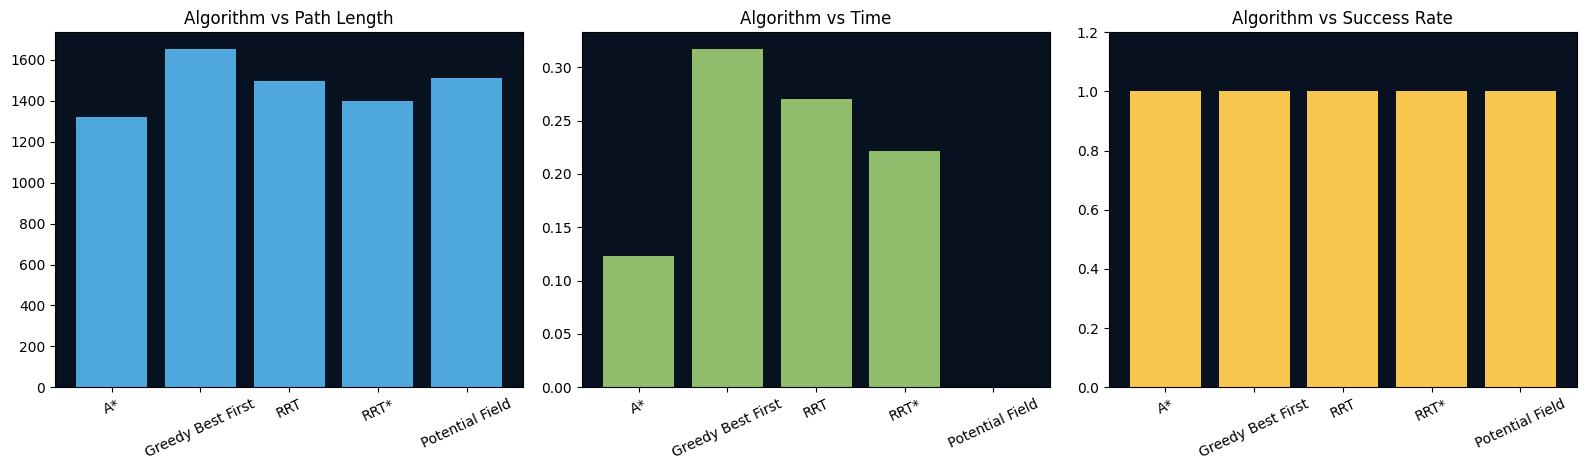

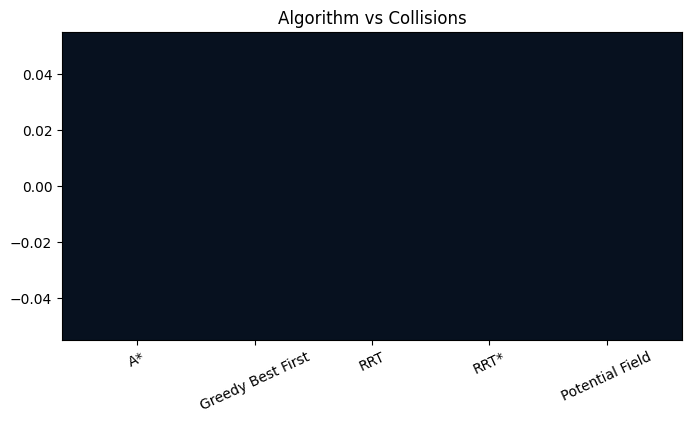

In [27]:
# 10. Performance Comparison

algorithm_names = [
    "A*",
    "Greedy Best First",
    "RRT",
    "RRT*",
    "Potential Field",
]

print("Comparison results")
print("-" * 74)
for name in algorithm_names:
    result = results[name]
    print(
        f"{name:18s} | "
        f"Path Length: {result['path_length']:8.2f} | "
        f"Time: {result['planning_time']:.4f} s | "
        f"Success: {str(result['success']):5s} | "
        f"Collisions: {result['collisions']}"
    )

path_lengths = [results[name]["path_length"] for name in algorithm_names]
planning_times = [results[name]["planning_time"] for name in algorithm_names]
success_values = [1 if results[name]["success"] else 0 for name in algorithm_names]
collision_values = [results[name]["collisions"] for name in algorithm_names]

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))

axes[0].bar(algorithm_names, path_lengths, color="#4ea8de")
axes[0].set_title("Algorithm vs Path Length")
axes[0].tick_params(axis="x", rotation=25)

axes[1].bar(algorithm_names, planning_times, color="#90be6d")
axes[1].set_title("Algorithm vs Time")
axes[1].tick_params(axis="x", rotation=25)

axes[2].bar(algorithm_names, success_values, color="#f9c74f")
axes[2].set_title("Algorithm vs Success Rate")
axes[2].set_ylim(0, 1.2)
axes[2].tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.bar(algorithm_names, collision_values, color="#f94144")
plt.title("Algorithm vs Collisions")
plt.xticks(rotation=25)
plt.show()

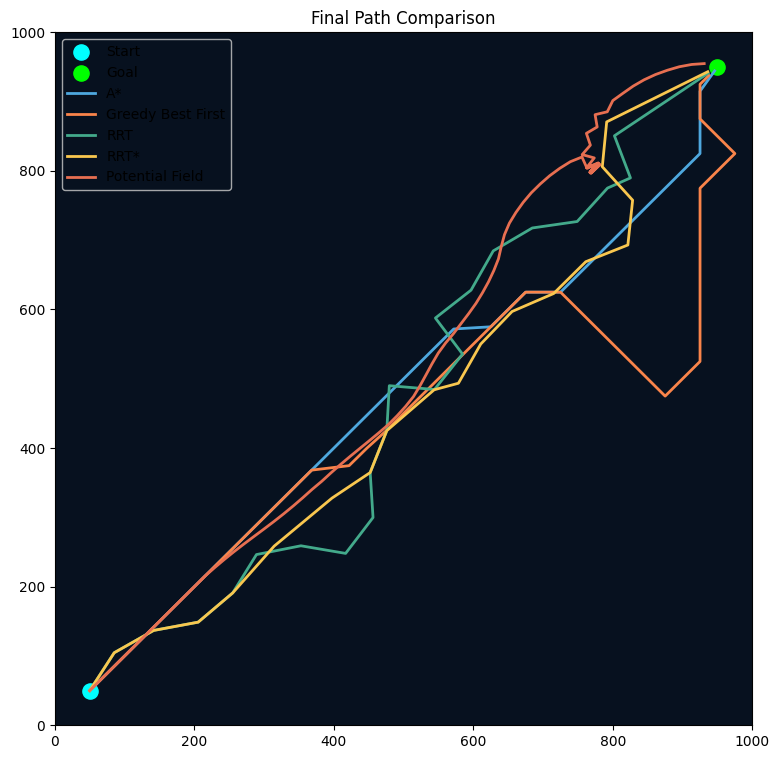

In [28]:
# 11. Visualization Comparison

color_map = {
    "A*": "#4ea8de",
    "Greedy Best First": "#f9844a",
    "RRT": "#43aa8b",
    "RRT*": "#f9c74f",
    "Potential Field": "#e76f51",
}

plt.figure(figsize=(9, 9))
plt.xlim(0, SPACE_WIDTH)
plt.ylim(0, SPACE_HEIGHT)
plt.gca().set_facecolor("#07111f")
plt.title("Final Path Comparison")

plt.scatter([START[0]], [START[1]], color="cyan", s=120, label="Start")
plt.scatter([GOAL[0]], [GOAL[1]], color="lime", s=120, label="Goal")

for name in algorithm_names:
    trail = results[name]["spacecraft_trail"]
    if len(trail) < 2:
        continue

    trail_array = np.array(trail)
    plt.plot(
        trail_array[:, 0],
        trail_array[:, 1],
        color=color_map[name],
        linewidth=2,
        label=name,
    )

plt.legend()
plt.show()

In [29]:
# 12. Conclusion

successful_algorithms = [name for name in algorithm_names if results[name]["success"]]

if successful_algorithms:
    best_algorithm = min(successful_algorithms, key=lambda name: results[name]["path_length"])
    print("Best successful algorithm in this run:", best_algorithm)
    print("Path length:", round(results[best_algorithm]["path_length"], 2))
    print("Planning time:", round(results[best_algorithm]["planning_time"], 4), "seconds")
else:
    print("No algorithm reached the goal in this run.")

fastest_algorithm = min(algorithm_names, key=lambda name: results[name]["planning_time"])
print("Fastest planner in this run:", fastest_algorithm)

Best successful algorithm in this run: A*
Path length: 1320.8
Planning time: 0.1234 seconds
Fastest planner in this run: Potential Field
